In [2]:
import ot
import warnings
import scipy.stats
import numpy as np
import pandas as pd
from scipy.stats import norm
from matplotlib import pyplot as plt
warnings.filterwarnings("ignore")

In [3]:
def kl_divergence(p, q):
    return np.sum(np.where(p != 0, p * np.log(p / q), 0))

In [4]:
def renyi_divergence(alpha, P, Q):
    if alpha == 1:
        out = np.sum(P * np.log(P / Q))
    elif alpha != 1:
        exp = np.sum(Q* ((P/Q) ** alpha))
        out = 1/(alpha - 1) * np.log(exp)
    return out

In [5]:
def wasserstein_distance(order, u_values, v_values):
    out = ot.wasserstein_1d(x_a=u_values, x_b=v_values, p=order)
    return out

In [6]:
dataset = pd.read_csv("ADULT/adult.csv",
    names=["Age", "Workclass", "fnlwgt", "Education", "Education-Num", "Martial Status",
        "Occupation", "Relationship", "Race", "Sex", "Capital Gain", "Capital Loss",
        "Hours per week", "Country", "Target"],sep=r'\s*,\s*',na_values="?")

datacount = dataset["Sex"].value_counts()

(array([    0.,  5000., 10000., 15000., 20000., 25000.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

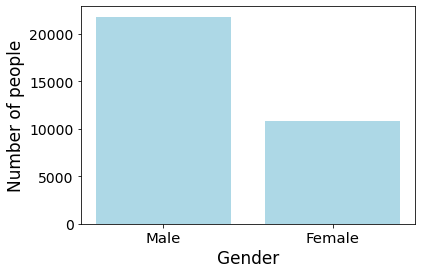

In [6]:
plt.figure(figsize=(6,4))
plt.bar(datacount.index,datacount,color='lightblue')
plt.ylabel('Number of people', fontsize=17)
plt.xlabel('Gender', fontsize=17)
plt.xticks(fontsize=14.8)
plt.yticks(fontsize=14)

In [7]:
def Gaussian_mechanism(scale, size, distribution_ = True):
    X = np.random.normal(loc=1, scale=scale, size=size)	
    Y = np.random.normal(loc=0, scale=scale, size=size)
    
    X = X + datacount
    Y = Y + datacount
    
    #X_dist = (X-scale)/size
    #Y_dist = (Y-scale)/size
    
    X_dist = scipy.special.softmax(X)
    Y_dist = scipy.special.softmax(Y)

    '''
    print('wasserstein_distance 1=', wasserstein_distance(X,Y))
    print('Renyi_Divergence=', renyi_divergence(1.2,X,Y))
    print('KL_divergence=', kl_divergence(X,Y))

    print('Scipy_KL=', scipy.stats.entropy(pk=X,qk=Y))
    print('wasserstein_distance 2=', wasserstein_distance(X,Y))
    '''
    if distribution_:
        X_out, Y_out = X_dist, Y_dist
    else:
        X_out, Y_out = X, Y
    
    return X_out, Y_out

In [8]:
def get_different_scale_order_renyi_wasser(order_start, order_end, order_num, scale_list, size):
    renyi_list = [[] for i in range(len(scale_list))]
    order_list = [[] for i in range(len(scale_list))]
    wasser_list = [[] for i in range(len(scale_list))]
    
    #plt.figure()
    
    for i in range(len(scale_list)):
        for order in np.linspace(order_start, order_end, order_num):
            order_list[i].append(order)
            
            X1,Y1 = Gaussian_mechanism(scale=scale_list[i], size=size, distribution_=True) 
            X2,Y2 = Gaussian_mechanism(scale=scale_list[i], size=size, distribution_=False)
            
            renyi_list[i].append(renyi_divergence(alpha=order, P=X1, Q=Y1).item())
            wasser_list[i].append(ot.wasserstein_1d(x_a=X2,x_b=Y2, p=order).item())
            
            #renyi_theory_list.append(RDP_Laplace_epsilon(alpha=order, scale=scale))
            #wasser_list.append(wasserstein_distance(X2,Y2).item())
            #KL1.append(scipy.stats.entropy(pk=X1,qk=Y1))

    return renyi_list, wasser_list, order_list

In [15]:
def plot_different_scale_order_renyi(renyi_list, order_list, scale_list):
    for i in range(len(scale_list)):
        plt.plot(
            order_list[i], np.array(renyi_list[i])/scale_list[i], 
            label='$\sigma$='+str(scale_list[i]), 
            alpha=0.6
            )
        #plt.plot(order_list, renyi_theory_list)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel('Order', fontsize=17)
    plt.ylabel('Privacy loss', fontsize=17)
    plt.legend(fontsize=15, loc=2)
    plt.savefig('result_dir/query/Adult_Gaussian_RDP_diff_order.png',
        bbox_inches='tight')
    plt.show()

In [16]:
def plot_different_scale_order_wasser(wasser_list, order_list, scale_list):
    for i in range(len(scale_list)):
        plt.plot(
            order_list[i], np.array(wasser_list[i])/scale_list[i], 
            label='$\sigma$='+str(scale_list[i]), 
            alpha=0.75
            )
        #plt.plot(order_list, renyi_theory_list)
        #(scale_list[i])

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel('Order', fontsize=17)
    plt.ylabel('Privacy loss', fontsize=17)
    plt.xlim(1,10)
    #plt.ylim(0,5)
    plt.legend(fontsize=15, loc=2)
    plt.savefig('result_dir/query/Adult_Gaussian_WDP_diff_order.png', 
        bbox_inches='tight')
    plt.show()

In [11]:
renyi_list, wasser_list, order_list = get_different_scale_order_renyi_wasser(
    order_start = 1, 
    order_end = 10, 
    order_num = 1000, 
    scale_list = [1,2,4],
    size = len(list(datacount))
)

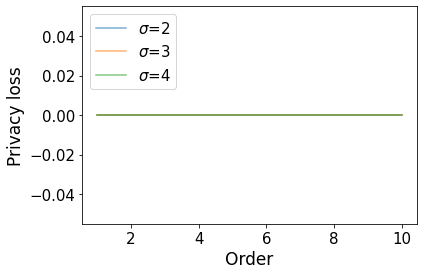

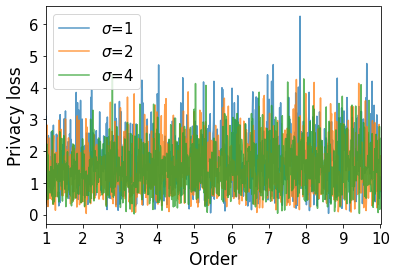

In [17]:
plot_different_scale_order_renyi(renyi_list, order_list, scale_list=[2,3,4])
plot_different_scale_order_wasser(wasser_list, order_list, scale_list=[1,2,4])

In [13]:
def RDP_Gaussian(alpha,sensitivity,sigma):
    return (alpha * (sensitivity**2) ) / (2*(sigma**2))

In [14]:
alpha = np.linspace(1,10,1000)

In [15]:
RDP_Gaussian_result_1 = RDP_Gaussian(alpha,1,1)
RDP_Gaussian_result_2 = RDP_Gaussian(alpha,1,2)
RDP_Gaussian_result_3 = RDP_Gaussian(alpha,1,4)

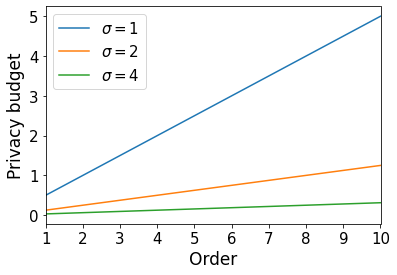

In [16]:
plt.plot(alpha,RDP_Gaussian_result_1,label='$\sigma=1$')
plt.plot(alpha,RDP_Gaussian_result_2,label='$\sigma=2$')
plt.plot(alpha,RDP_Gaussian_result_3,label='$\sigma=4$')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Order', fontsize=17)
plt.ylabel('Privacy budget', fontsize=17)
#plt.ylim(0,5)
plt.xlim(1,10)
plt.legend(fontsize=15, loc=2)

In [17]:
def RDP_Laplace(alpha,sensitivity,lambda_):
    if alpha > 1:
        item1 = (1/(alpha-1))
        item2 = alpha/(2*alpha-1) * np.exp((alpha-1)/lambda_)
        item3 = (alpha-1)/(2*alpha-1) * np.exp(-alpha/lambda_)
        out_ = item1 * np.log(item2 + item3)
    elif alpha == 1:
        item1 = 1/lambda_
        item2 = np.exp(-1/lambda_) 
        out_ = item1 + item2 - 1
    return out_

In [18]:
RDP_Laplace_result_1=[]
for alpha_i in alpha:
    RDP_Laplace_result_1.append(RDP_Laplace(alpha_i,1,1))
RDP_Laplace_result_2=[]
for alpha_i in alpha:
    RDP_Laplace_result_2.append(RDP_Laplace(alpha_i,1,2))
RDP_Laplace_result_3=[]
for alpha_i in alpha:
    RDP_Laplace_result_3.append(RDP_Laplace(alpha_i,1,4))

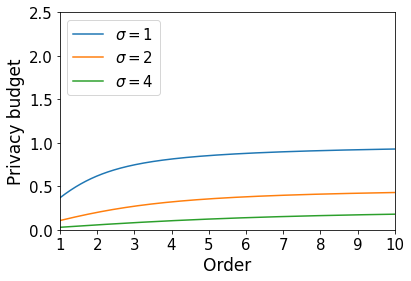

In [19]:
plt.plot(alpha,RDP_Laplace_result_1,label='$\sigma=1$')
plt.plot(alpha,RDP_Laplace_result_2,label='$\sigma=2$')
plt.plot(alpha,RDP_Laplace_result_3,label='$\sigma=4$')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Order', fontsize=17)
plt.ylabel('Privacy budget', fontsize=17)
plt.ylim(0,2.5)
plt.xlim(1,10)
plt.legend(fontsize=15, loc=2)

In [20]:
def classical_DP_Laplace(alpha,sensitivity,lambda_):
    return 1/lambda_

In [21]:
classical_DP_Laplace_result_1=[]
for alpha_i in alpha:
    classical_DP_Laplace_result_1.append(classical_DP_Laplace(alpha_i,1,1))
classical_DP_Laplace_result_2=[]
for alpha_i in alpha:
    classical_DP_Laplace_result_2.append(classical_DP_Laplace(alpha_i,1,2))
classical_DP_Laplace_result_3=[]
for alpha_i in alpha:
    classical_DP_Laplace_result_3.append(classical_DP_Laplace(alpha_i,1,4))

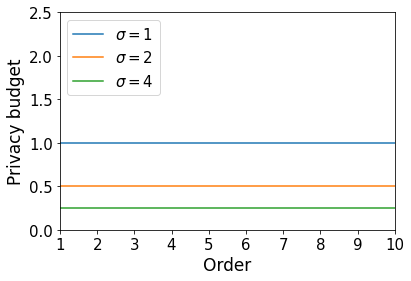

In [23]:
plt.plot(alpha,classical_DP_Laplace_result_1,label='$\sigma=1$')
plt.plot(alpha,classical_DP_Laplace_result_2,label='$\sigma=2$')
plt.plot(alpha,classical_DP_Laplace_result_3,label='$\sigma=4$')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Order', fontsize=17)
plt.ylabel('Privacy budget', fontsize=17)
plt.ylim(0,2.5)
plt.xlim(1,10)
plt.legend(fontsize=15, loc=2)